In [ ]:
# Global Benchmark Comparison: Bengaluru vs Leading Mobility Cities

#Comparative analysis of congestion, travel efficiency, and emissions trends across Bengaluru, Zurich, Amsterdam, and Singapore (2020–2025).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
df = pd.read_excel("Data/City_Benchmark_2020_2025.xlsx")
df.head()

In [ ]:
df.info()
df.describe(include="all")

In [32]:
blr.columns

Index(['City', 'Year', 'Congestion %', '10 km time', 'Rush hour speed', 'Rank',
       'Congestion-relevant car trips/day', 'Estimated private car trips/day',
       'Avg Trip km', 'Emission Factor',
       'Vehicle Kilometres Travelled (VKT) (km/year)', 'Unit',
       'CO₂e (kg/year)', 'CO₂e Tonnes'],
      dtype='str')

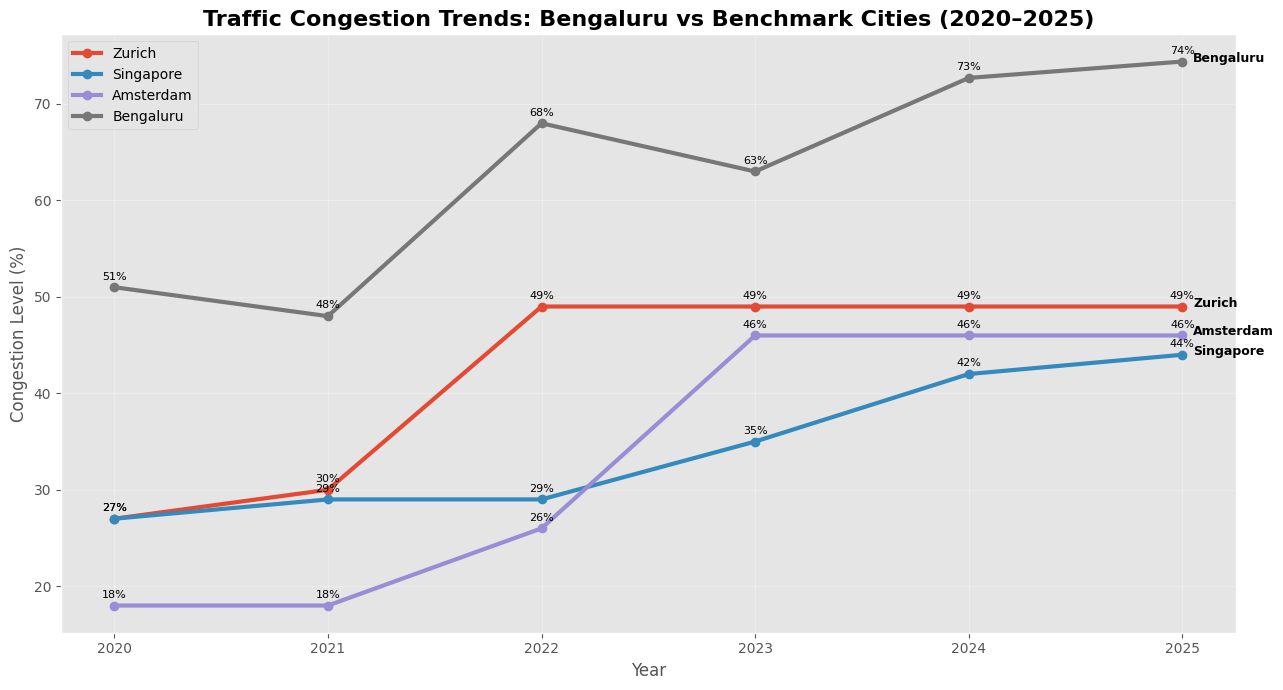

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------
# LOAD FILES
# ---------------------------------------------------
bench = pd.read_excel("Data/City_Benchmark_2020_2025.xlsx")
blr = pd.read_excel("Data/Bengaluru_Traffic_Cars.xlsx")

# ---------------------------------------------------
# CLEAN BENGALURU FILE DYNAMICALLY
# ---------------------------------------------------
blr.columns = blr.columns.str.strip()

year_col = [c for c in blr.columns if "year" in c.lower()][0]
cong_col = [c for c in blr.columns if "congestion" in c.lower()][0]

blr = blr[[year_col, cong_col]].copy()
blr.columns = ["Year", "Congestion %"]
blr["City"] = "Bengaluru"

# ---------------------------------------------------
# CREATE COMBINED DATAFRAME
# ---------------------------------------------------
combined = pd.concat(
    [
        bench[["City", "Year", "Congestion %"]],
        blr[["City", "Year", "Congestion %"]]
    ],
    ignore_index=True
)

# numeric safety
combined["Year"] = pd.to_numeric(combined["Year"], errors="coerce")
combined["Congestion %"] = pd.to_numeric(combined["Congestion %"], errors="coerce")

combined = combined.dropna()

# ---------------------------------------------------
# PLOT
# ---------------------------------------------------
plt.figure(figsize=(13,7))

for city in combined["City"].unique():

    city_df = combined[combined["City"] == city].sort_values("Year")

    plt.plot(
        city_df["Year"],
        city_df["Congestion %"],
        marker="o",
        linewidth=3,
        label=city
    )

    # data labels
    for x, y in zip(city_df["Year"], city_df["Congestion %"]):
        plt.text(
            x,
            y + 0.8,
            f"{y:.0f}%",
            ha="center",
            fontsize=8
        )

    # city label at end
    x_last = city_df["Year"].iloc[-1]
    y_last = city_df["Congestion %"].iloc[-1]

    plt.text(
        x_last + 0.05,
        y_last,
        city,
        fontsize=9,
        weight="bold"
    )

plt.title(
    "Traffic Congestion Trends: Bengaluru vs Benchmark Cities (2020–2025)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Congestion Level (%)")
plt.xticks(range(2020, 2026))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "outputs/charts/Benchmarking_traffic_congestion_trends_bengaluruvsbenchmark.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
df["Minutes_10km"] = (
    df["10 km time"]
    .str.extract(r'(\d+)')
    .astype(int)
)

In [ ]:
#bengaluru file
blr = pd.read_excel("Data/Bengaluru_Traffic_Cars.xlsx")

blr_small = blr[["Year", "10 km time"]].copy()
blr_small["City"] = "Bengaluru"

# benchmark file
bench_small = df[["City", "Year", "10 km time"]].copy()

# Combine
time_combined = pd.concat([bench_small, blr_small], ignore_index=True)


time_combined["Minutes_10km"] = (
    time_combined["10 km time"]
    .astype(str)
    .str.extract(r'(\d+)')
    .astype(int)
)

# Plot
plt.figure(figsize=(13,7))

for city in time_combined["City"].unique():
    
    city_df = time_combined[time_combined["City"] == city]

    plt.plot(
        city_df["Year"],
        city_df["Minutes_10km"],
        marker="o",
        linewidth=3,
        label=city
    )

    for x, y in zip(city_df["Year"], city_df["Minutes_10km"]):
        plt.text(x, y+0.3, f"{y}m", ha="center", fontsize=8)

plt.title(
    "Average Time Required to Travel 10 km: Bengaluru vs Benchmark Cities",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Minutes")
plt.xticks(range(2020, 2026))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("outputs/charts/Benchmarking_avergae_time_required_to_travel_10km.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Bengaluru file
blr = pd.read_excel("Data/Bengaluru_Traffic_Cars.xlsx")

blr_speed = blr[["Year", "Rush hour speed"]].copy()
blr_speed["City"] = "Bengaluru"

# Benchmark file
bench_speed = df[["City", "Year", "Rush hour speed"]].copy()

# Combine
speed_combined = pd.concat([bench_speed, blr_speed], ignore_index=True)

# Ensure numeric
speed_combined["Rush hour speed"] = pd.to_numeric(
    speed_combined["Rush hour speed"],
    errors="coerce"
)

# Plot
plt.figure(figsize=(13,7))

for city in speed_combined["City"].unique():
    
    city_df = speed_combined[speed_combined["City"] == city]

    plt.plot(
        city_df["Year"],
        city_df["Rush hour speed"],
        marker="o",
        linewidth=3,
        label=city
    )

    for x, y in zip(city_df["Year"], city_df["Rush hour speed"]):
        plt.text(
            x,
            y + 0.3,
            f"{y:.1f}",
            ha="center",
            fontsize=8
        )

plt.title(
    "Rush Hour Traffic Speed: Bengaluru vs Benchmark Cities",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Speed (km/h)")
plt.xticks(range(2020, 2026))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("outputs/charts/Benchmarking_rush_hour_traffic_speed.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Bengaluru 2025 (latest)
blr = pd.read_excel("Data/Bengaluru_Traffic_Cars.xlsx")

blr_2025 = blr[blr["Year"] == 2025][
    ["Year", "Congestion %", "Rush hour speed", "Rank"]
].copy()

blr_2025["City"] = "Bengaluru"

# Benchmark latest (2025)
bench_2025 = df[df["Year"] == 2025][
    ["City", "Year", "Congestion %", "Rush hour speed", "Rank"]
].copy()

# Combine
snap = pd.concat([bench_2025, blr_2025], ignore_index=True)

# Bubble size (smaller rank = bigger bubble)
snap["Bubble"] = 5000 / snap["Rank"]

# Plot
plt.figure(figsize=(12,8))

plt.scatter(
    snap["Congestion %"],
    snap["Rush hour speed"],
    s=snap["Bubble"],
    alpha=0.7
)

for i in range(len(snap)):
    plt.text(
        snap["Congestion %"].iloc[i] + 0.5,
        snap["Rush hour speed"].iloc[i],
        snap["City"].iloc[i],
        fontsize=10,
        weight="bold"
    )

plt.title(
    "Urban Mobility Positioning (2025): Congestion vs Traffic Speed",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Congestion Level (%)")
plt.ylabel("Rush Hour Speed (km/h)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/charts/Benchmarking_urban_mobility_positioning.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Bengaluru
blr = pd.read_excel("Data/Bengaluru_Traffic_Cars.xlsx")
blr["City"] = "Bengaluru"

blr_small = blr[["City", "Year", "Congestion %"]]

# Benchmark
bench_small = df[["City", "Year", "Congestion %"]]

# Combine
chg = pd.concat([bench_small, blr_small], ignore_index=True)

# 2020 vs 2025
start = chg[chg["Year"] == 2020][["City", "Congestion %"]]
end = chg[chg["Year"] == 2025][["City", "Congestion %"]]

start.columns = ["City", "Start"]
end.columns = ["City", "End"]

delta = start.merge(end, on="City")
delta["Change"] = delta["End"] - delta["Start"]

# Sort
delta = delta.sort_values("Change")

# Plot
plt.figure(figsize=(12,7))

bars = plt.barh(delta["City"], delta["Change"])

for bar in bars:
    val = bar.get_width()
    plt.text(
        val + 0.5,
        bar.get_y() + bar.get_height()/2,
        f"{val:+.0f}%",
        va="center",
        fontsize=10
    )

plt.title(
    "Change in Congestion Since 2020 (2025 vs 2020)",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Percentage Point Change")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/charts/Benchmarking_change_in_congestion_since2020.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
df.columns

In [ ]:
df.columns = (
    df.columns
    .str.replace("%", "percent", regex=False)
    .str.replace("/", "_per_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

df.columns

In [ ]:
numeric_cols = [
    "year",
    "congestion_percent",
    "rush_hour_speed",
    "rank",
    "congestion-relevant_car_trips_per_day",
    "estimated_private_car_trips_per_day",
    "avg_trip_km",
    "emission_factor",
    "vehicle_kilometres_travelled_vkt_km_per_year"
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

df.info()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load files
blr = pd.read_excel("Data/Bengaluru_Traffic_Cars.xlsx")
bench = pd.read_excel("Data/City_Benchmark_2020_2025.xlsx")


blr["City"] = "Bengaluru"

# Combine
full = pd.concat([bench, blr], ignore_index=True)

cities = ["Bengaluru", "Zurich", "Amsterdam", "Singapore"]

fig, axes = plt.subplots(2, 2, figsize=(16,12))
axes = axes.flatten()

for i, city in enumerate(cities):

    city_df = full[full["City"] == city].copy()

    cols = [
        "Congestion %",
        "Rush hour speed",
        "Rank",
        "Estimated private car trips/day",
        "Avg Trip km",
        "CO₂e Tonnes"
    ]

    city_df = city_df[cols]

 
    for c in cols:
        city_df[c] = pd.to_numeric(city_df[c], errors="coerce")

    corr = city_df.corr()

    sns.heatmap(
        corr,
        annot=True,
        cmap="RdYlGn",
        fmt=".2f",
        ax=axes[i]
    )

    axes[i].set_title(city, fontsize=14, weight="bold")

plt.suptitle(
    "City-wise Correlation Matrices",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()
plt.savefig("outputs/charts/Benchmarking_city-wise_correlation_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

plt.style.use("ggplot")

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------
bench = pd.read_excel("Data/City_Benchmark_2020_2025.xlsx")
blr = pd.read_excel("Data/Bengaluru_Traffic_Cars.xlsx")

# Bengaluru clean
blr.columns = blr.columns.str.strip()

year_col = [c for c in blr.columns if "year" in c.lower()][0]
cong_col = [c for c in blr.columns if "congestion" in c.lower()][0]

blr = blr[[year_col, cong_col]].copy()
blr.columns = ["Year", "Congestion %"]
blr["City"] = "Bengaluru"

# Combine
hist = pd.concat([
    bench[["City","Year","Congestion %"]],
    blr[["City","Year","Congestion %"]]
], ignore_index=True)

# numeric
hist["Year"] = pd.to_numeric(hist["Year"], errors="coerce")
hist["Congestion %"] = pd.to_numeric(hist["Congestion %"], errors="coerce")

hist = hist.dropna()

# ---------------------------------------------------
# COLORS
# ---------------------------------------------------
colors = {
    "Bengaluru":"red",
    "Zurich":"green",
    "Amsterdam":"purple",
    "Singapore":"orange"
}

# ---------------------------------------------------
# PLOT
# ---------------------------------------------------
plt.figure(figsize=(15,8))

for city in hist["City"].unique():

    temp = hist[hist["City"] == city].sort_values("Year")

    x = temp["Year"]
    y = temp["Congestion %"]

    color = colors[city]

    # Historical
    plt.plot(
        x, y,
        marker="o",
        linewidth=3,
        color=color,
        label=f"{city} Historical"
    )

    for a,b in zip(x,y):
        plt.text(a, b+0.4, f"{b:.0f}", ha="center", fontsize=8)

    # Forecast model
    model = ExponentialSmoothing(
        y,
        trend="add",
        seasonal=None
    ).fit()

    future = model.forecast(5)
    future.index = [2026,2027,2028,2029,2030]

    # Join line
    plt.plot(
        [2025,2026],
        [y.iloc[-1], future.iloc[0]],
        linestyle="--",
        linewidth=2,
        color=color
    )

    # Forecast
    plt.plot(
        future.index,
        future.values,
        marker="o",
        linestyle="--",
        linewidth=2.8,
        color=color,
        label=f"{city} Forecast"
    )

    for a,b in zip(future.index, future.values):
        plt.text(a, b+0.4, f"{b:.1f}", ha="center", fontsize=8)

plt.title(
    "Traffic Congestion Forecast for Global Cities (2020–2030)",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Year")
plt.ylabel("Congestion (%)")
plt.xticks(range(2020,2031))
plt.grid(True, alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig("outputs/charts/Benchmarking_Traffic_congestion_forecast_global_cities.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
blr = pd.read_excel("Data/Bengaluru_Traffic_Cars.xlsx")
print(blr.columns)
print(blr[["Year","CO₂e Tonnes"]])

In [ ]:
# ==========================================================
# FINAL REALISTIC FORECAST MODEL (ALL CITIES)
# DAMPED HOLT EXPONENTIAL SMOOTHING
# Best for short annual datasets (2020-2025)
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

# ----------------------------------------------------------
# LOAD FILES
# ----------------------------------------------------------
blr = pd.read_excel("Data/Bengaluru_Traffic_Cars.xlsx")
bench = pd.read_excel("Data/City_Benchmark_2020_2025.xlsx")

blr.columns = blr.columns.str.strip()
bench.columns = bench.columns.str.strip()

# ----------------------------------------------------------
# AUTO DETECT BENGALURU COLUMNS
# ----------------------------------------------------------
year_col = [c for c in blr.columns if "year" in c.lower()][0]

co2_col = None
for c in blr.columns:
    if "tonne" in c.lower():
        co2_col = c
        break

# Bengaluru
blr_em = blr[[year_col, co2_col]].copy()
blr_em.columns = ["Year", "CO2"]
blr_em["City"] = "Bengaluru"

# ----------------------------------------------------------
# BENCHMARK
# ----------------------------------------------------------
bench_co2_col = None
for c in bench.columns:
    if "tonne" in c.lower():
        bench_co2_col = c
        break

bench_em = bench[["City", "Year", bench_co2_col]].copy()
bench_em.columns = ["City", "Year", "CO2"]

# ----------------------------------------------------------
# COMBINE
# ----------------------------------------------------------
em = pd.concat([blr_em, bench_em], ignore_index=True)

em["Year"] = pd.to_numeric(em["Year"], errors="coerce")
em["CO2"] = pd.to_numeric(em["CO2"], errors="coerce")
em = em.dropna()

# ----------------------------------------------------------
# COLORS
# ----------------------------------------------------------
colors = {
    "Bengaluru": "red",
    "Zurich": "green",
    "Amsterdam": "purple",
    "Singapore": "orange"
}

cities = ["Bengaluru", "Zurich", "Amsterdam", "Singapore"]

# ==========================================================
# SMALL MULTIPLES (BEST VISUAL)
# ==========================================================
fig, axes = plt.subplots(2, 2, figsize=(16,10))
axes = axes.flatten()

for i, city in enumerate(cities):

    temp = (
        em[em["City"] == city]
        .groupby("Year", as_index=False)["CO2"]
        .mean()
        .sort_values("Year")
    )

    x = temp["Year"].tolist()
    y = temp["CO2"].tolist()

    # ------------------------------------------------------
    # DAMPED HOLT MODEL
    # ------------------------------------------------------
    model = ExponentialSmoothing(
        pd.Series(y),
        trend="add",
        damped_trend=True,
        seasonal=None
    ).fit()

    future = model.forecast(5).tolist()
    future_years = [2026, 2027, 2028, 2029, 2030]

    ax = axes[i]

    # Historical
    ax.plot(
        x, y,
        marker="o",
        linewidth=3,
        color=colors[city],
        label="Historical"
    )

    # Join line
    ax.plot(
        [2025, 2026],
        [y[-1], future[0]],
        linestyle="--",
        linewidth=2,
        color=colors[city]
    )

    # Forecast
    ax.plot(
        future_years,
        future,
        marker="o",
        linestyle="--",
        linewidth=2.5,
        color=colors[city],
        label="Forecast"
    )

    # Labels
    for a,b in zip(x,y):
        ax.text(a, b, f"{int(b):,}", fontsize=7)

    for a,b in zip(future_years,future):
        ax.text(a, b, f"{int(b):,}", fontsize=7)

    ax.set_title(city, fontsize=14, weight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("CO₂ Tonnes")
    ax.grid(True, alpha=0.3)
    ax.legend()

# ----------------------------------------------------------
plt.suptitle(
    "Urban Transport CO₂ Emissions Forecast (2020–2030)\nDamped Holt Exponential Smoothing",
    fontsize=18,
    weight="bold"
)

plt.tight_layout()
plt.savefig("outputs/charts/Benchmarking_Urban_Transport_CO2_Emissions_Forecast.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Bengaluru 2030 policy simulation

baseline_2030_co2 = blr_forecast.iloc[-1] if "blr_forecast" in globals() else None

baseline_2030_co2 = 10034390  # forecast output (2030)

policy_scenarios = pd.DataFrame({
    "Scenario": [
        "No Action Baseline",
        "10% Trip Reduction",
        "20% Trip Reduction",
        "30% Trip Reduction",
        "20% EV Transition",
        "10% Shorter Avg Trips",
        "Combined Policy Package"
    ],
    "CO2_2030_Tonnes": [
        baseline_2030_co2,
        baseline_2030_co2 * 0.90,
        baseline_2030_co2 * 0.80,
        baseline_2030_co2 * 0.70,
        baseline_2030_co2 * 0.84,
        baseline_2030_co2 * 0.90,
        baseline_2030_co2 * 0.55
    ]
})

policy_scenarios["CO2_Saved_Tonnes"] = (
    baseline_2030_co2 - policy_scenarios["CO2_2030_Tonnes"]
)

policy_scenarios

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = policy_scenarios.copy()
df = df[df["Scenario"] != "No Action Baseline"].copy()

baseline = policy_scenarios.loc[
    policy_scenarios["Scenario"]=="No Action Baseline",
    "CO2_2030_Tonnes"
].values[0]

# -------------------------
# infer intervention size %
# -------------------------
df["Intervention %"] = [
    10,20,30,20,10,45
]

# -------------------------
# Fully dynamic metrics
# -------------------------
df["CO2 Reduction"] = df["CO2_Saved_Tonnes"]
df["Reduction %"] = df["CO2_Saved_Tonnes"] / baseline * 100
df["Efficiency"] = df["CO2_Saved_Tonnes"] / df["Intervention %"]
df["Residual Cleanliness"] = (baseline - df["CO2_2030_Tonnes"]) + 1
df["Impact Score"] = df["CO2_Saved_Tonnes"]

# normalize all to 10
metrics = [
    "CO2 Reduction",
    "Reduction %",
    "Efficiency",
    "Residual Cleanliness",
    "Impact Score"
]

for col in metrics:
    df[col] = df[col] / df[col].max() * 10

# -------------------------
# Radar
# -------------------------
categories = metrics
N = len(categories)

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(10,10))
ax = plt.subplot(111, polar=True)

for _, row in df.iterrows():

    vals = row[metrics].tolist()
    vals += vals[:1]

    ax.plot(angles, vals, linewidth=2.2, marker="o", label=row["Scenario"])
    ax.fill(angles, vals, alpha=0.05)

ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11, weight="bold")

ax.set_ylim(0,10)
ax.set_yticks([2,4,6,8,10])

plt.title(
    "Fully Data-Driven Bengaluru Policy Comparison",
    fontsize=18,
    weight="bold",
    pad=25
)

plt.legend(
    bbox_to_anchor=(1.35,1.10),
    fontsize=9
)

plt.tight_layout()
plt.savefig("outputs/charts/Benchmarking_Bengaluru_Policy_Comparision.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------------------
# DATA
# ---------------------------------------------------
df = policy_scenarios.copy()
df = df[df["Scenario"] != "No Action Baseline"].copy()

df["Effort_%"] = [10, 20, 30, 20, 10, 45]

# ---------------------------------------------------
# PLOT
# ---------------------------------------------------
plt.figure(figsize=(15,8))

plt.scatter(
    df["Effort_%"],
    df["CO2_Saved_Tonnes"],
    s=260,
    alpha=0.9
)

# ---------------------------------------------------
# CUSTOM LABEL OFFSETS (fix overlap)
# ---------------------------------------------------
offsets = {
    "10% Trip Reduction": (0.6, 60000),
    "10% Shorter Avg Trips": (0.6, -60000),
    "20% Trip Reduction": (0.6, 30000),
    "20% EV Transition": (0.6, -30000),
    "30% Trip Reduction": (0.6, 30000),
    "Combined Policy Package": (0.6, 30000)
}

for _, row in df.iterrows():

    x = row["Effort_%"]
    y = row["CO2_Saved_Tonnes"]
    label = row["Scenario"]

    dx, dy = offsets[label]

    plt.text(
        x + dx,
        y + dy,
        label,
        fontsize=10,
        weight="bold"
    )

# ---------------------------------------------------
# FORMAT
# ---------------------------------------------------
plt.title(
    "Bengaluru Policy Efficiency Frontier",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Estimated Implementation Effort (%)")
plt.ylabel("CO₂ Saved (Tonnes)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/charts/Benchmarking_Bengaluru_policy_efficient_frontier.png", dpi=300, bbox_inches="tight")
plt.show()